In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [10]:
DATA_ROOT = '../data'

In [17]:
results = pd.read_csv(f'{DATA_ROOT}/Pearsons_results.csv', index_col = 0, header = 0)
results['train_pearsons'] = 1 - results['train_loss']

In [18]:
results[results['train_loss'] > 1]

,train_loss,test_loss,stopped_early,in_features,train_pearsons
AARD,1.259466,1.250090,1.0,13,-0.259466
ABCA12,1.125649,1.118480,1.0,22,-0.125649
ABCA13,1.162875,1.131125,1.0,4,-0.162875
ABRA,1.071197,1.091052,1.0,2,-0.071197
ACMSD,1.558364,1.570730,1.0,2,-0.558364
...,...,...,...,...,...
ZNHIT3,1.013865,1.043532,1.0,2,-0.013865
ZNHIT6,1.374732,1.353516,1.0,8,-0.374732
ZPBP,1.110005,1.160862,1.0,11,-0.110005
ZSWIM2,1.023877,0.995684,1.0,30,-0.023877


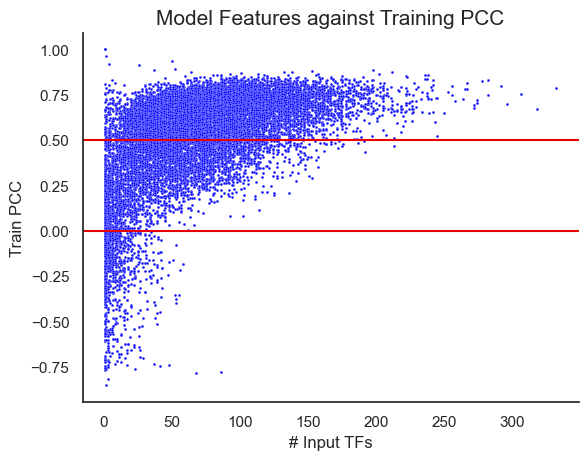

In [49]:
sns.set_theme(style = 'white')

sns.scatterplot(results, y='train_pearsons', x = 'in_features', s = 4, color = '#0000ff', legend = False)
plt.ylabel('Train PCC')
plt.xlabel('# Input TFs')
plt.title('Model Features against Training PCC', fontsize = 15)
sns.despine()
plt.axhline(0.5, color = '#e60000')
plt.axhline(0.0, color = '#e60000')
plt.savefig('feature_number_vs_trainingPCC', dpi = 300)


In [13]:
results[results.index.isin(['CYP2C9', 'DBX1', 'FIGLA', 'WAPL', 'ZNF512B'])]

,train_loss,test_loss,stopped_early,in_features
CYP2C9,4.017730e-01,3.866926e-01,NaN,18
DBX1,5.960464e-08,1.192093e-07,1.0,1
FIGLA,1.609056e+00,1.634987e+00,1.0,1
WAPL,3.902208e-01,3.804647e-01,1.0,14
ZNF512B,1.192093e-07,1.192093e-07,1.0,1


# Correlation and MSE plots

In [14]:
from plotting_functions import create_pearsons_violin

In [15]:
results.columns = ['train_loss', 'dataset', 't', 't2']

In [ ]:
genewise_correlations = pd.read_csv('./data/genewise_correlations', index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: './data/genewise_correlations'

In [ ]:
genewise_correlations['LogMSE'] = np.log(genewise_correlations['MSE']+1)

In [ ]:
np.sort(genewise_correlations[genewise_correlations['dataset'] == 'Train']['pearsons'])

array([-0.9987995 , -0.90427183, -0.82733209, ...,  0.96437079,
        0.96532573,  0.97125173])

In [ ]:
np.sort(1 - results['train_loss'])

array([-0.93830931, -0.9336729 , -0.87022805, ...,  0.9595716 ,
        0.97724217,  0.99998087])

<Axes: >

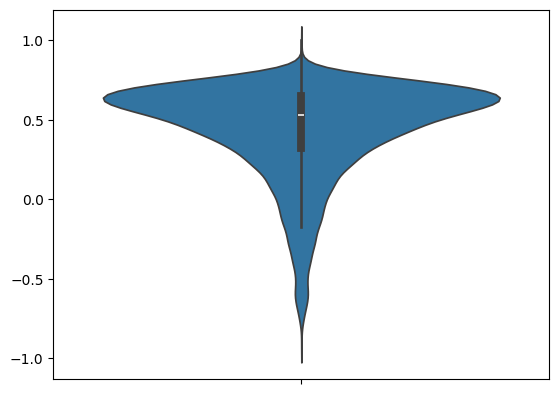

In [ ]:
sns.violinplot(np.sort(1 - results['test_loss']))

<Axes: >

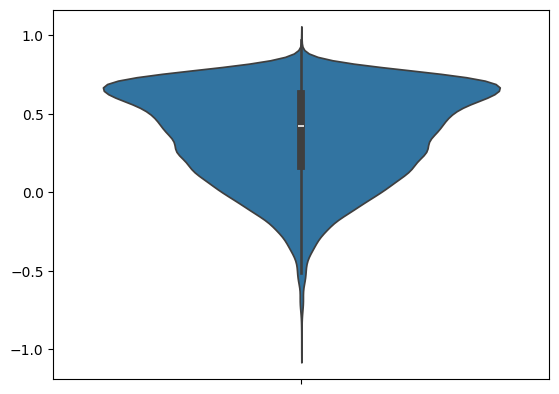

In [ ]:
sns.violinplot(np.sort(genewise_correlations[genewise_correlations['dataset'] == 'Train']['pearsons']))

In [ ]:
results.columns = ['train_loss', 'dataset', 't', 't2']

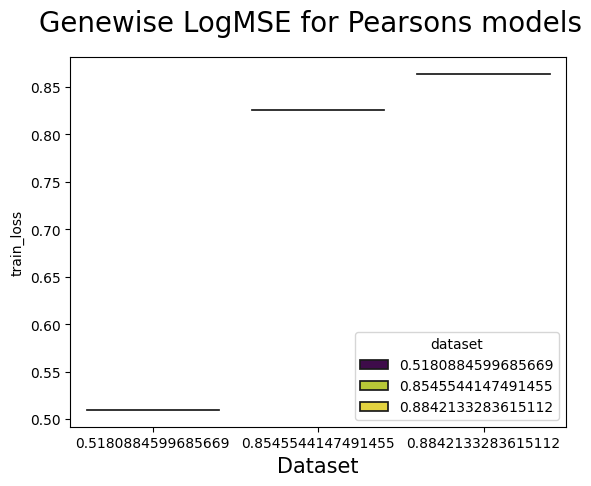

In [ ]:
create_pearsons_violin(results, y_col='train_loss', title = 'Genewise LogMSE for Pearsons models', file_title = 'genewise_LogMSE_PEARSONS', size = '500', temp = 'k2', hegiht= 'k3')

In [ ]:
from_train_losses = results[['train_loss', 'test_loss']].melt()
from_train_losses.columns = ['dataset', 'value']

In [ ]:
from_train_losses['value'] = 1 - from_train_losses['value']

In [ ]:
from_train_losses

,dataset,value
0,train_loss,0.031068
1,train_loss,-0.174456
2,train_loss,-0.094459
3,train_loss,0.417640
4,train_loss,0.681664
...,...,...
32195,test_loss,-0.214892
32196,test_loss,0.581442
32197,test_loss,0.728245
32198,test_loss,0.761174


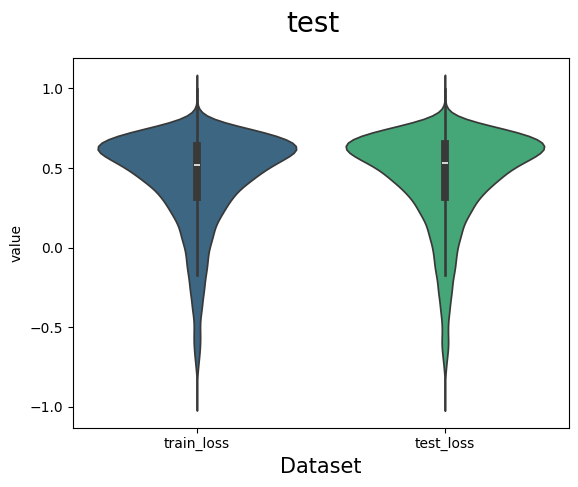

In [ ]:
create_pearsons_violin(from_train_losses, y_col = 'value', title = 'test', file_title = 'TEMP')